# Lab 4 — Zadanie 4
## SAM na danych hiperspektralnych + kalibracja Sentinel-2 danymi lotniczymi
### Rzeka Odra — sceny 008 / 013 / 015



## 0. Instalacja zależności

In [ ]:
# !pip install spectral numpy matplotlib pandas scipy scikit-learn rasterio pyproj

## 1. Konfiguracja

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

# ── Scieżki ────────────────────────────────────────────────────────────────────
SCENE    = "008"    # zmień na 013 lub 015
DATA_DIR = Path(r"C:\Users\mzawa\eolabs\lab_5\data\images")
HDR_PATH = DATA_DIR / f"221000_Odra_HS_Blok_A_{SCENE}_VS_join_atm.hdr"

# Biblioteka spektralna wygenerowana przez viewer.py (zadanie 2)
LIBRARY_CSV = Path(r"C:\Users\mzawa\eolabs\lab_5\spectral_library.csv")

# Katalog z danymi Sentinel-2 (rozpakowana scena z zadania 3)
S2_DIR = Path(r"C:\Users\mzawa\eolabs\lab_5\data\sentinel2")

print(f"HDR: {HDR_PATH.exists()}")
print(f"Biblioteka: {LIBRARY_CSV.exists()}")

HDR: True
Biblioteka: True


## 2. Wczytanie danych hiperspektralnych i biblioteki spektralnej

In [2]:
import spectral.io.envi as envi

img  = envi.open(str(HDR_PATH))
meta = img.metadata

wavelengths = np.array([float(w) for w in meta["wavelength"]])
IGNORE_VAL  = 15000.0
REFL_SCALE  = 10000.0
N_BANDS     = img.nbands   # 456

print(f"Scena {SCENE}: {img.nrows} x {img.ncols} x {N_BANDS} pasm")
print(f"Zakres: {wavelengths[0]:.1f} - {wavelengths[-1]:.1f} nm")

def find_band(target_nm):
    return int(np.argmin(np.abs(wavelengths - target_nm)))

# ── Wczytanie biblioteki spektralnej (format z viewer.py) ─────────────────────
# Kolumny: class, row, col, wavelength_nm_414.1, wavelength_nm_417.3, ...
lib_df = pd.read_csv(LIBRARY_CSV)
print(f"\nBiblioteka: {len(lib_df)} probek, klasy: {lib_df['class'].unique().tolist()}")

# Wyodrebnij tablice X i etykiety y
wl_cols = [c for c in lib_df.columns if c.startswith('wavelength_nm_') or c.startswith('band_')]
X_lib   = lib_df[wl_cols].values.astype(np.float64)   # (n_samples, 456)
y_lib   = lib_df['class'].values

# Przebuduj slownik referencyjnych widm (jak w Lab_3)
reference_spectra = {}
for cls in np.unique(y_lib):
    mask = y_lib == cls
    reference_spectra[cls] = X_lib[mask, :]   # (n, 456)
    print(f"  {cls:15s}: {mask.sum()} probek")

Scena 008: 4300 x 2001 x 456 pasm
Zakres: 414.1 - 2498.9 nm

Biblioteka: 6 probek, klasy: ['water', 'vegetation', 'forest', 'bare soil', 'urban', 'shadow']
  bare soil      : 1 probek
  forest         : 1 probek
  shadow         : 1 probek
  urban          : 1 probek
  vegetation     : 1 probek
  water          : 1 probek


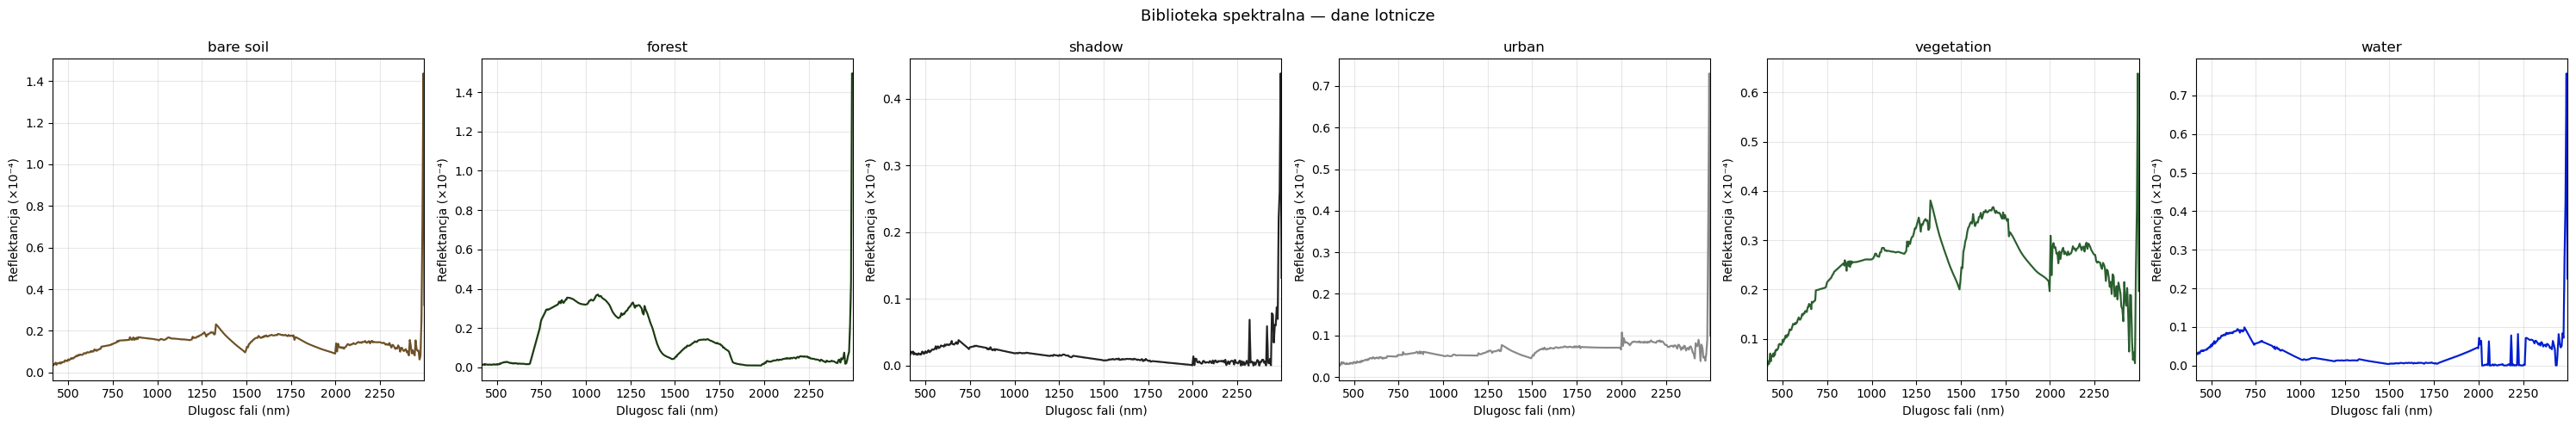

In [3]:
# ── Wizualizacja biblioteki spektralnej ───────────────────────────────────────
# (odpowiednik komórki 23 z Lab_3, tutaj na 456 pasmach)
CLASS_COLORS = {
    'water':      '#001DD1',
    'vegetation': '#2A5E2E',
    'forest':     '#1A3A10',
    'bare soil':  '#6D5026',
    'urban':      '#888888',
    'shadow':     '#222222',
}

fig, axes = plt.subplots(1, len(reference_spectra), figsize=(5*len(reference_spectra), 5))
if len(reference_spectra) == 1:
    axes = [axes]

for ax, (cls, spectra) in zip(axes, reference_spectra.items()):
    color = CLASS_COLORS.get(cls, '#444444')
    # maskuj NaN i wartosci no-data
    clean = spectra.copy()
    clean[clean >= IGNORE_VAL] = np.nan
    mean_s = np.nanmean(clean, axis=0)
    q5, q95 = np.nanpercentile(clean, [5, 95], axis=0)
    ax.fill_between(wavelengths, q5, q95, alpha=0.25, color=color)
    ax.plot(wavelengths, mean_s, color=color, linewidth=1.5)
    ax.set_title(cls, fontsize=12)
    ax.set_xlabel('Dlugosc fali (nm)')
    ax.set_ylabel('Reflektancja (×10⁻⁴)')
    ax.set_xlim([wavelengths[0], wavelengths[-1]])
    ax.grid(True, alpha=0.3)

fig.suptitle('Biblioteka spektralna — dane lotnicze', fontsize=13)
fig.tight_layout()
plt.savefig('spectral_library_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. SAM na danych hiperspektralnych

Identyczna logika jak w Lab_3 (komórka 28), ale na 456 pasmach zamiast 6.  
Ze względu na rozmiar scen (~17 GB) przetwarzamy dane wierszami (nie ładujemy całości do RAM).

In [4]:
def spectral_angle(spectra: np.ndarray, ref: np.ndarray) -> np.ndarray:
    """
    Kąt spektralny [rad] między kazdym wierszem macierzy `spectra`
    a wektorem referencyjnym `ref`.
    spectra: (N, B)  ref: (B,)
    """
    dot  = np.dot(spectra, ref)
    norm = np.linalg.norm(spectra, axis=1) * np.linalg.norm(ref)
    # clip do [-1, 1] żeby uniknąć NaN z arccos
    cos  = np.clip(np.divide(dot, norm, where=norm > 0,
                             out=np.full_like(dot, np.nan)), -1.0, 1.0)
    return np.arccos(cos)


# Widma referencyjne (mediana każdej klasy) — analogia do Lab_3
ref_spectra = {
    cls: np.nanmedian(np.where(spectra >= IGNORE_VAL, np.nan, spectra), axis=0)
    for cls, spectra in reference_spectra.items()
}
classes = list(ref_spectra.keys())
print('Klasy SAM:', classes)

Klasy SAM: ['bare soil', 'forest', 'shadow', 'urban', 'vegetation', 'water']


In [5]:
# ── Obliczenie map kątów SAM dla całej sceny (wiersz po wierszu) ──────────────
# Wynik: (n_klas, nrows, ncols) — osobna mapa dla każdej klasy

n_classes = len(classes)
sam_maps  = np.full((n_classes, img.nrows, img.ncols), np.nan, dtype=np.float32)

print(f'Obliczanie SAM dla sceny {SCENE} ({img.nrows} wierszy)...')
chunk = 50   # liczba wierszy na raz — dostosuj do dostępnej RAM

for row_start in range(0, img.nrows, chunk):
    row_end = min(row_start + chunk, img.nrows)
    # Wczytaj blok: (chunk, ncols, nbands)
    block = img.read_subimage(
        range(row_start, row_end), range(img.ncols)
    ).astype(np.float64)
    # Maskuj no-data
    block[block >= IGNORE_VAL] = np.nan
    block[block < 0]           = np.nan
    # Reshape: (chunk*ncols, nbands)
    spectra_2d = block.reshape(-1, N_BANDS)
    # Oblicz SAM dla każdej klasy
    for k, cls in enumerate(classes):
        angles = spectral_angle(spectra_2d, ref_spectra[cls])
        sam_maps[k, row_start:row_end, :] = angles.reshape(row_end - row_start, img.ncols)

    if row_start % 200 == 0:
        print(f'  {row_start}/{img.nrows}', end='\r')

print(f'  {img.nrows}/{img.nrows} — gotowe!')

Obliczanie SAM dla sceny 008 (4300 wierszy)...
  4300/4300 — gotowe!


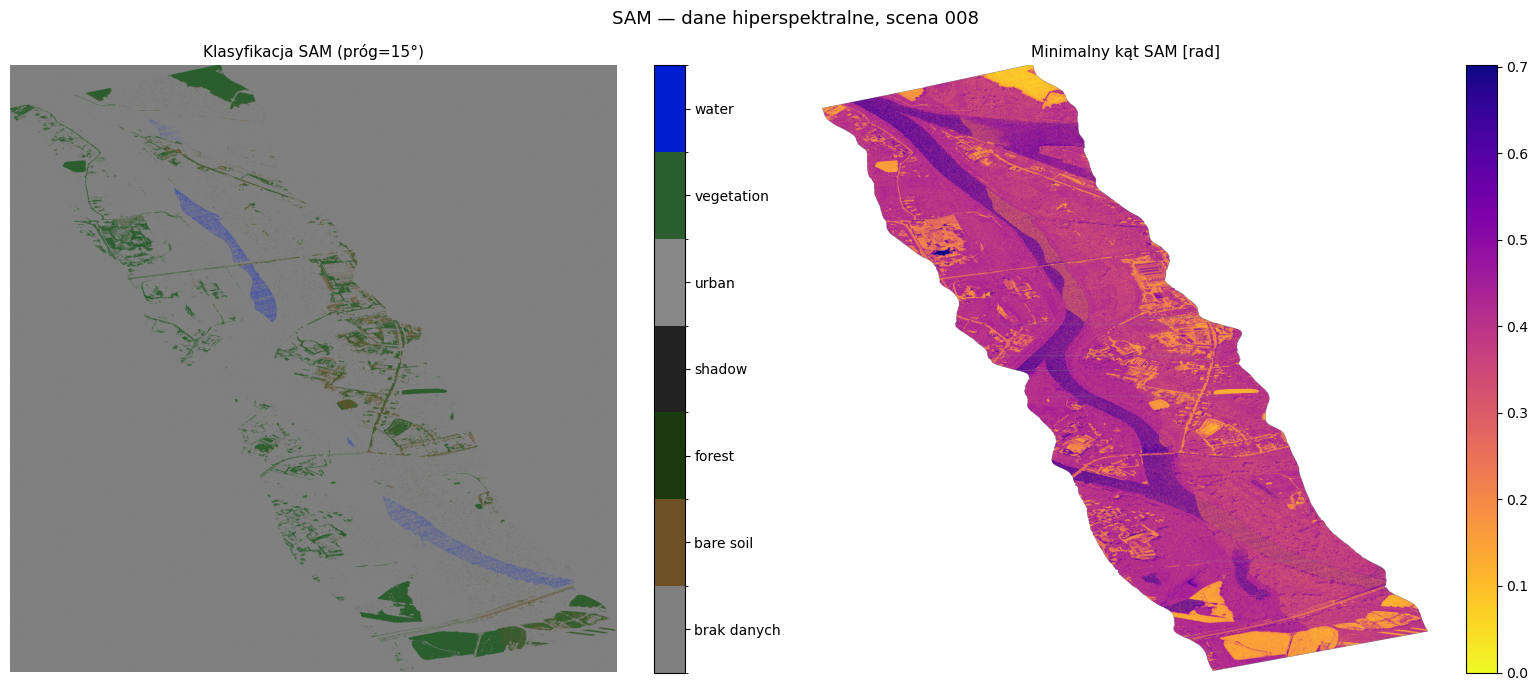

In [6]:
# ── Mapa SAM: klasyfikacja przez najmniejszy kąt ──────────────────────────────
# Dla każdego piksela: klasa = argmin(kąt SAM po wszystkich klasach)
sam_class_map = np.argmin(sam_maps, axis=0)  # (nrows, ncols)
# Piksele no-data (NaN we wszystkich klasach) → -1
all_nan = np.all(np.isnan(sam_maps), axis=0)
sam_class_map[all_nan] = -1

# Opcjonalnie: próg kąta — piksele z min-kątem > threshold = 'nieznane'
SAM_THRESHOLD_RAD = np.deg2rad(15)   # 15° — typowa wartość dla danych hiperspektralnych
min_angle = np.nanmin(sam_maps, axis=0)
sam_class_map[min_angle > SAM_THRESHOLD_RAD] = -1

# ── Wizualizacja mapy klasyfikacji SAM ────────────────────────────────────────
color_list  = ['gray'] + [CLASS_COLORS.get(c, '#999') for c in classes]
class_ids   = [-1] + list(range(n_classes))
cmap_sam    = mcolors.ListedColormap(color_list)
norm_sam    = mcolors.BoundaryNorm([-1.5] + [i + 0.5 for i in range(-1, n_classes)], cmap_sam.N)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Mapa klas SAM
im = axes[0].imshow(sam_class_map, cmap=cmap_sam, norm=norm_sam, aspect='auto')
axes[0].set_title(f'Klasyfikacja SAM (próg={np.rad2deg(SAM_THRESHOLD_RAD):.0f}°)', fontsize=11)
axes[0].axis('off')
cbar = plt.colorbar(im, ax=axes[0], ticks=class_ids)
cbar.set_ticklabels(['brak danych'] + classes)

# Mapa minimalnych kątów SAM
vmax_ang = np.nanpercentile(min_angle[~all_nan], 98)
im2 = axes[1].imshow(min_angle, cmap='plasma_r', vmin=0, vmax=vmax_ang, aspect='auto')
axes[1].set_title('Minimalny kąt SAM [rad]', fontsize=11)
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1])

fig.suptitle(f'SAM — dane hiperspektralne, scena {SCENE}', fontsize=13)
fig.tight_layout()
plt.savefig(f'sam_airborne_{SCENE}.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Random Forest z cechami SAM (adaptacja Lab_3)

W Lab_3 cechy = [B1..B6, sam_Soil, sam_Water, NDVI].  
Tu cechy = [sam_klasa_1, ..., sam_klasa_N, NDCI, NDWI] — nie wczytujemy wszystkich 456 pasm do RAM.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# ── Zbuduj macierz cech z biblioteki spektralnej ──────────────────────────────
# X_lib: (n_samples, 456)   y_lib: (n_samples,)

# Cechy SAM: kąty względem każdej klasy referencyjnej
sam_features = []
for cls in classes:
    ref = ref_spectra[cls]
    clean = np.where(X_lib >= IGNORE_VAL, np.nan, X_lib)
    angles = spectral_angle(clean, ref)
    sam_features.append(angles.reshape(-1, 1))

X_sam = np.hstack(sam_features)  # (n_samples, n_classes)

# Cechy spektralne: NDCI (chlorofil), NDWI (woda)
b_670 = find_band(670);  b_700 = find_band(700)
b_550 = find_band(550);  b_860 = find_band(860)

def safe_idx(arr, numerator_idx, denominator_idx):
    a, b_ = arr[:, numerator_idx], arr[:, denominator_idx]
    return np.where(a + b_ != 0, (a - b_) / (a + b_), np.nan)

NDCI_lib = safe_idx(X_lib, b_700, b_670).reshape(-1, 1)
NDWI_lib = safe_idx(X_lib, b_550, b_860).reshape(-1, 1)  # McFeeters NDWI

X_train_full = np.hstack([X_sam, NDCI_lib, NDWI_lib])
# Zastąp NaN wartościami mediany kolumny
col_medians = np.nanmedian(X_train_full, axis=0)
for j in range(X_train_full.shape[1]):
    mask_nan = np.isnan(X_train_full[:, j])
    X_train_full[mask_nan, j] = col_medians[j]

feature_names = [f'sam_{c}' for c in classes] + ['NDCI', 'NDWI']
print(f'Macierz cech: {X_train_full.shape}  →  cechy: {feature_names}')

Macierz cech: (6, 8)  →  cechy: ['sam_bare soil', 'sam_forest', 'sam_shadow', 'sam_urban', 'sam_vegetation', 'sam_water', 'NDCI', 'NDWI']


In [11]:
# ── Podział na train / test i trening RF (jak w Lab_3) ───────────────────────

# Sprawdź ile probek ma każda klasa
from collections import Counter
print(Counter(y_lib))

# Usuń klasy z tylko 1 próbką (nie nadają się do stratified split)
counts  = Counter(y_lib)
keep    = np.array([counts[c] >= 2 for c in y_lib])
X_train_full = X_train_full[keep]
y_lib_filtered = y_lib[keep]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_train_full, y_lib, test_size=0.25, stratify=y_lib, random_state=42
)

clf = RandomForestClassifier(
    n_estimators    = 200,
    max_depth       = 10,
    max_features    = 'sqrt',
    class_weight    = 'balanced',
    max_samples     = 0.8,
    min_samples_leaf= 2,
    n_jobs          = -1,
    random_state    = 42,
)
clf.fit(X_tr, y_tr)

y_pred = clf.predict(X_te)
acc    = accuracy_score(y_te, y_pred)
print(f'Dokladnosc na zbiorze testowym: {acc*100:.1f}%\n')

# Macierz pomylek
unique_classes = np.unique(y_lib)
cm = confusion_matrix(y_te, y_pred, labels=unique_classes)
df_cm = pd.DataFrame(cm, index=unique_classes, columns=unique_classes)
print('Macierz pomylek:')
print(df_cm)

# Ważność cech
fig, ax = plt.subplots(figsize=(8, 4))
importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
importances.plot.bar(ax=ax, color='steelblue')
ax.set_title('Waznosc cech (Mean Decrease Impurity)')
ax.set_ylabel('MDI')
fig.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Counter({'water': 1, 'vegetation': 1, 'forest': 1, 'bare soil': 1, 'urban': 1, 'shadow': 1})


IndexError: boolean index did not match indexed array along axis 0; size of axis is 0 but size of corresponding boolean axis is 6

In [12]:
# ── Klasyfikacja RF całej sceny (wiersz po wierszu) ───────────────────────────
print('Klasyfikacja RF całej sceny...')

labels_as_numbers = {cls: i for i, cls in enumerate(unique_classes)}
rf_class_map = np.full((img.nrows, img.ncols), -1, dtype=np.int8)

for row_start in range(0, img.nrows, chunk):
    row_end = min(row_start + chunk, img.nrows)
    h = row_end - row_start
    # Kąty SAM z preobliczonych map
    sam_block = sam_maps[:, row_start:row_end, :].reshape(n_classes, -1).T  # (h*w, n_classes)

    # NDCI i NDWI z surowych danych
    block = img.read_subimage(range(row_start, row_end), range(img.ncols)).astype(np.float64)
    block[block >= IGNORE_VAL] = np.nan
    b2d   = block.reshape(-1, N_BANDS)
    ndci  = np.where(b2d[:, b_700] + b2d[:, b_670] != 0,
                     (b2d[:, b_700] - b2d[:, b_670]) / (b2d[:, b_700] + b2d[:, b_670]), np.nan).reshape(-1,1)
    ndwi  = np.where(b2d[:, b_550] + b2d[:, b_860] != 0,
                     (b2d[:, b_550] - b2d[:, b_860]) / (b2d[:, b_550] + b2d[:, b_860]), np.nan).reshape(-1,1)

    X_block = np.hstack([sam_block, ndci, ndwi])
    # Uzupelnij NaN medianami treningowymi
    for j in range(X_block.shape[1]):
        nans = np.isnan(X_block[:, j])
        X_block[nans, j] = col_medians[j]

    y_num = np.array([labels_as_numbers[c] for c in clf.predict(X_block)])
    rf_class_map[row_start:row_end, :] = y_num.reshape(h, img.ncols)

    if row_start % 200 == 0:
        print(f'  {row_start}/{img.nrows}', end='\r')

print(f'  {img.nrows}/{img.nrows} — gotowe!')

# Wizualizacja
n_uc = len(unique_classes)
colors_rf = ['gray'] + [CLASS_COLORS.get(c, '#999') for c in unique_classes]
cmap_rf   = mcolors.ListedColormap(colors_rf)
norm_rf   = mcolors.BoundaryNorm([-1.5] + [i + 0.5 for i in range(n_uc)], cmap_rf.N)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(rf_class_map, cmap=cmap_rf, norm=norm_rf, aspect='auto')
ax.set_title(f'Klasyfikacja RF (SAM + NDCI + NDWI) — scena {SCENE}', fontsize=12)
ax.axis('off')
cbar = plt.colorbar(im, ax=ax, ticks=[-1] + list(range(n_uc)))
cbar.set_ticklabels(['brak danych'] + list(unique_classes))
fig.tight_layout()
plt.savefig(f'rf_classification_{SCENE}.png', dpi=150, bbox_inches='tight')
plt.show()

Klasyfikacja RF całej sceny...


NameError: name 'unique_classes' is not defined

## 5. Kalibracja Sentinel-2 danymi lotniczymi




In [13]:
import rasterio
from rasterio.enums import Resampling
from pyproj import Transformer
from scipy import stats

# ── Wczytanie pasm S2 ─────────────────────────────────────────────────────────
# Pasma odpowiadajace dlugosciom fal uzytym w SAM
S2_BAND_MAP = {
    'B02': 492,   # ~490 nm
    'B03': 560,   # ~550 nm
    'B04': 665,   # ~665 nm
    'B05': 705,   # ~700 nm
    'B8A': 865,   # ~860 nm
}

def find_s2_file(root, band):
    for pattern in [f'*_{band}_10m.jp2', f'*_{band}_20m.jp2', f'*_{band}.jp2']:
        hits = list(root.rglob(pattern))
        if hits:
            return hits[0]
    return None

# Znajdz rozpakowana scene S2
s2_scenes = [d for d in S2_DIR.iterdir() if d.is_dir() and d.suffix == '.SAFE']
if not s2_scenes:
    s2_scenes = [d for d in S2_DIR.iterdir() if d.is_dir()]
s2_root = s2_scenes[0] if s2_scenes else S2_DIR
print(f'Scena S2: {s2_root.name}')

# Wczytaj pasma S2 do slownika {band_name: (data, profile)}
with rasterio.open(find_s2_file(s2_root, 'B04')) as ref_src:
    s2_shape     = (ref_src.height, ref_src.width)
    s2_crs       = ref_src.crs
    s2_transform = ref_src.transform

s2_data = {}
for band, wl in S2_BAND_MAP.items():
    fp = find_s2_file(s2_root, band)
    if fp:
        with rasterio.open(fp) as src:
            arr = src.read(1, out_shape=(1, *s2_shape),
                           resampling=Resampling.bilinear).astype(np.float64)
        arr[arr <= 0] = np.nan
        s2_data[band] = arr / 10000.0
        print(f'  {band} ({wl} nm): OK  shape={arr.shape}')
    else:
        print(f'  {band}: NIE ZNALEZIONO')

Scena S2: S2B_MSIL2A_20221007T100029_N0510_R122_T33UYR_20240822T003402.SAFE
  B02 (492 nm): OK  shape=(10980, 10980)
  B03 (560 nm): OK  shape=(10980, 10980)
  B04 (665 nm): OK  shape=(10980, 10980)
  B05 (705 nm): OK  shape=(10980, 10980)
  B8A (865 nm): OK  shape=(10980, 10980)


In [14]:
# ── Przeliczenie wspolrzednych pikseli biblioteki ──────────────────────────────
# Piksele z viewer.py sa w ukladzie CS2000 Z6 (ukl. danych lotniczych)
# Musimy je przeprojektowac na siatke S2 (EPSG:32634 lub 32633 — sprawdz CRS sceny)

# CRS danych lotniczych (z naglowka ENVI)
AIR_CRS = 'EPSG:2177'   # ETRS89 / CS2000 Z6 = EPSG:2177

# map info: UL_X=6509736, UL_Y=5580712 (Z6), pixel=1m
MAP_INFO = {
    '008': (6509736.0, 5580712.0),
    '013': (6510302.0, 5581560.0),
    '015': (6517216.0, 5581457.0),
}
ul_x, ul_y = MAP_INFO[SCENE]
pixel_size = 1.0

# Wspolrzedne pikseli biblioteki w CS2000 Z6
lib_rows = lib_df['row'].values
lib_cols = lib_df['col'].values
lib_x_cs2000 = ul_x + lib_cols * pixel_size   # easting
lib_y_cs2000 = ul_y - lib_rows * pixel_size   # northing

# Transformacja CS2000 -> CRS sceny S2
transformer = Transformer.from_crs(AIR_CRS, s2_crs.to_epsg() or str(s2_crs), always_xy=True)
lib_x_s2, lib_y_s2 = transformer.transform(lib_x_cs2000, lib_y_cs2000)

# Pixel indices w siatce S2
from rasterio.transform import rowcol as rio_rowcol
lib_rows_s2, lib_cols_s2 = rio_rowcol(s2_transform, lib_x_s2, lib_y_s2)
lib_rows_s2 = np.clip(lib_rows_s2, 0, s2_shape[0]-1)
lib_cols_s2 = np.clip(lib_cols_s2, 0, s2_shape[1]-1)

print(f'Przykladowe piksele biblioteki w ukladzie S2:')
for i in range(min(5, len(lib_df))):
    print(f'  [{lib_df["class"].iloc[i]:12s}]  '
          f'air=({lib_rows[i]}, {lib_cols[i]})  '
          f'S2=({lib_rows_s2[i]}, {lib_cols_s2[i]})')

Przykladowe piksele biblioteki w ukladzie S2:
  [water       ]  air=(1675, 832)  S2=(1807, 2403)
  [vegetation  ]  air=(118, 677)  S2=(1652, 2381)
  [forest      ]  air=(1196, 901)  S2=(1759, 2408)
  [bare soil   ]  air=(2397, 1110)  S2=(1878, 2434)
  [urban       ]  air=(1880, 1233)  S2=(1826, 2444)


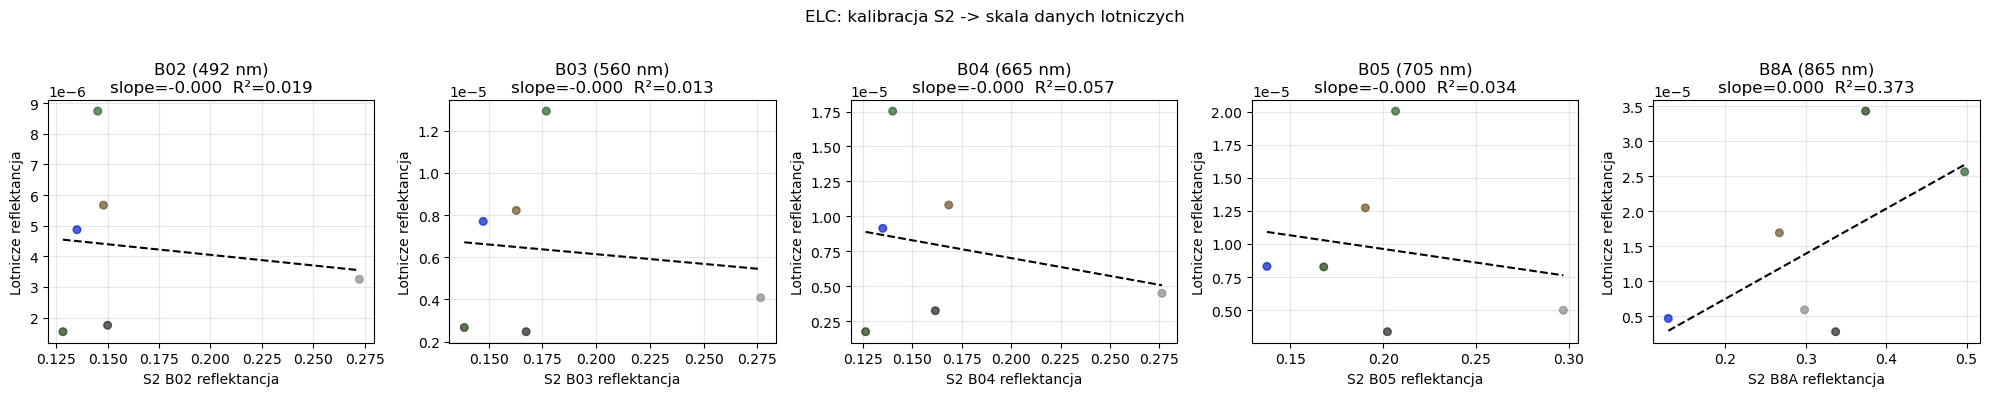


Parametry ELC (Y=slope*X+intercept):
Pasmo     Slope  Intercept     R²
----------------------------------
B02     -0.0000   0.000005  0.019
B03     -0.0000   0.000008  0.013
B04     -0.0000   0.000012  0.057
B05     -0.0000   0.000014  0.034
B8A      0.0001  -0.000005  0.373


In [15]:
# ── Empirical Line Calibration: regresja dla każdego pasma S2 ─────────────────
# X = reflektancja S2 w danym pikselu biblioteki
# Y = "ground truth": reflektancja lotnicza uśredniona do odpowiedniej długości fali

elc_params = {}   # band -> (slope, intercept, r2)

fig, axes = plt.subplots(1, len(S2_BAND_MAP), figsize=(4*len(S2_BAND_MAP), 4))

for ax, (band, target_nm) in zip(axes, S2_BAND_MAP.items()):
    air_idx = find_band(target_nm)

    # Reflektancja lotnicza (z biblioteki CSV, przeliczona na [0,1])
    col_name = wl_cols[air_idx] if air_idx < len(wl_cols) else None
    if col_name is None:
        continue
    y_air = lib_df[col_name].values.astype(np.float64) / REFL_SCALE

    # Reflektancja S2 dla tych samych pikseli
    s2_arr = s2_data.get(band)
    if s2_arr is None:
        continue
    x_s2 = s2_arr[lib_rows_s2, lib_cols_s2]

    # Usuń NaN
    valid = ~(np.isnan(x_s2) | np.isnan(y_air))
    if valid.sum() < 3:
        print(f'{band}: za malo punktow kalibracyjnych ({valid.sum()})')
        elc_params[band] = (1.0, 0.0, 0.0)
        continue

    slope, intercept, r, _, _ = stats.linregress(x_s2[valid], y_air[valid])
    elc_params[band] = (slope, intercept, r**2)

    # Wykres
    ax.scatter(x_s2[valid], y_air[valid], c=[CLASS_COLORS.get(c, '#999')
               for c in lib_df['class'].values[valid]], s=30, alpha=0.7, zorder=3)
    x_line = np.linspace(np.nanmin(x_s2[valid]), np.nanmax(x_s2[valid]), 50)
    ax.plot(x_line, slope*x_line + intercept, 'k--', linewidth=1.5)
    ax.set_xlabel(f'S2 {band} reflektancja')
    ax.set_ylabel('Lotnicze reflektancja')
    ax.set_title(f'{band} ({target_nm} nm)\nslope={slope:.3f}  R²={r**2:.3f}')
    ax.grid(True, alpha=0.3)

fig.suptitle('ELC: kalibracja S2 -> skala danych lotniczych', fontsize=12)
fig.tight_layout()
plt.savefig('elc_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nParametry ELC (Y=slope*X+intercept):')
print(f'{"Pasmo":<6} {"Slope":>8} {"Intercept":>10} {"R²":>6}')
print('-'*34)
for band, (s, i, r2) in elc_params.items():
    print(f'{band:<6} {s:>8.4f} {i:>10.6f} {r2:>6.3f}')

In [16]:
# ── Zastosowanie kalibracji ELC do calej sceny S2 ─────────────────────────────
s2_cal = {}
for band, (slope, intercept, r2) in elc_params.items():
    arr = s2_data.get(band)
    if arr is None:
        continue
    # Y_cal = slope * X + intercept
    cal = slope * arr + intercept
    cal[cal < 0]   = 0.0  # reflektancja nie moze byc ujemna
    cal[np.isnan(arr)] = np.nan
    s2_cal[band] = cal

print('Kalibracja ELC zastosowana do pasm S2:')
for band in s2_cal:
    orig = s2_data[band]
    cal  = s2_cal[band]
    print(f'  {band}: mean przed={np.nanmean(orig):.5f}  '
          f'po={np.nanmean(cal):.5f}  '
          f'delta={np.nanmean(cal)-np.nanmean(orig):+.5f}')

Kalibracja ELC zastosowana do pasm S2:
  B02: mean przed=0.16756  po=0.00000  delta=-0.16755
  B03: mean przed=0.18751  po=0.00001  delta=-0.18751
  B04: mean przed=0.18529  po=0.00001  delta=-0.18529
  B05: mean przed=0.22839  po=0.00001  delta=-0.22838
  B8A: mean przed=0.36397  po=0.00002  delta=-0.36396


## 6. SAM na skalibrowanych danych Sentinel-2

In [17]:
# ── Buduj widma S2 (przed i po kalibracji) dla każdego piksela ────────────────
# Kształt: (nrows_s2 * ncols_s2, n_s2_bands)

band_order = list(S2_BAND_MAP.keys())   # ['B02','B03','B04','B05','B8A']
n_s2       = len(band_order)
n_pix      = s2_shape[0] * s2_shape[1]

def build_s2_matrix(data_dict):
    """Scal slownik pasm S2 w macierz (n_pix, n_s2_bands)."""
    bands = [data_dict[b].ravel() for b in band_order if b in data_dict]
    return np.column_stack(bands)

S2_raw_mat = build_s2_matrix(s2_data)
S2_cal_mat = build_s2_matrix(s2_cal)

# ── Widma referencyjne przetransponowane do 5 pasm S2 ─────────────────────────
# (uśredniamy wąskie pasma hiperspektralne do szerokości pasm S2)
def resample_to_s2(ref_hs):
    """ref_hs: (456,) hiperspektralne → (5,) odpowiadające pasmom S2."""
    out = []
    for band, target_nm in S2_BAND_MAP.items():
        # Prosta: pobierz jednotno pasmo po dlugosci fali
        # Dokkladniej: usrednij po szerokosci pasma S2
        S2_FWHM = {'B02': 65, 'B03': 35, 'B04': 30, 'B05': 15, 'B8A': 20}  # nm
        fwhm = S2_FWHM.get(band, 20)
        mask = (wavelengths >= target_nm - fwhm/2) & (wavelengths <= target_nm + fwhm/2)
        out.append(np.nanmean(ref_hs[mask]) / REFL_SCALE if mask.any() else np.nan)
    return np.array(out)

ref_s2 = {cls: resample_to_s2(ref_spectra[cls]) for cls in classes}
print('Widma referencyjne (5 pasm S2, reflektancja [0,1]):')
for cls, r in ref_s2.items():
    print(f'  {cls:15s}: {np.round(r, 4)}')

MemoryError: Unable to allocate 4.49 GiB for an array with shape (120560400, 5) and data type float64

In [18]:
# ── Mapy kątów SAM dla S2 (przed i po kalibracji) ─────────────────────────────
def sam_maps_s2(s2_mat, refs):
    """Zwraca (n_klas, n_pix) macierz katow SAM."""
    result = np.full((len(refs), n_pix), np.nan)
    for k, (cls, ref) in enumerate(refs.items()):
        result[k] = spectral_angle(s2_mat, ref)
    return result

sam_s2_raw = sam_maps_s2(S2_raw_mat, ref_s2)   # (n_klas, n_pix)
sam_s2_cal = sam_maps_s2(S2_cal_mat, ref_s2)

def reshape_s2_sam(sam_mat):
    return sam_mat.reshape(n_classes, *s2_shape)

sam_s2_raw_3d = reshape_s2_sam(sam_s2_raw)
sam_s2_cal_3d = reshape_s2_sam(sam_s2_cal)

# Klasyfikacja przez najmniejszy kąt
SAM_THRESHOLD_S2 = np.deg2rad(20)  # luźniejszy próg dla węższych pasm S2

def classify_by_min_angle(sam_3d, threshold):
    cls_map  = np.argmin(sam_3d, axis=0)
    min_ang  = np.nanmin(sam_3d, axis=0)
    all_nan  = np.all(np.isnan(sam_3d), axis=0)
    cls_map[all_nan]              = -1
    cls_map[min_ang > threshold]  = -1
    return cls_map

cls_raw = classify_by_min_angle(sam_s2_raw_3d, SAM_THRESHOLD_S2)
cls_cal = classify_by_min_angle(sam_s2_cal_3d, SAM_THRESHOLD_S2)

# ── Wizualizacja: S2 surowe vs S2 skalibrowane ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, cls_map, title in zip(axes,
    [cls_raw, cls_cal],
    ['SAM na S2 (bez kalibracji)', 'SAM na S2 (po kalibracji ELC)']):

    im = ax.imshow(cls_map, cmap=cmap_sam, norm=norm_sam, aspect='auto')
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    cbar = plt.colorbar(im, ax=ax, ticks=[-1] + list(range(n_classes)))
    cbar.set_ticklabels(['brak/nieznane'] + classes)

fig.suptitle('Wpływ kalibracji ELC na klasyfikację SAM — Sentinel-2', fontsize=13)
fig.tight_layout()
plt.savefig('sam_s2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'ref_s2' is not defined

## 7. Porównanie: SAM lotnicze vs SAM S2 (skalibrowane)

In [19]:
# ── Statystyki klasyfikacji ────────────────────────────────────────────────────
def class_stats(cls_map, name):
    print(f'\n--- {name} ---')
    total = cls_map.size
    unkn  = np.sum(cls_map == -1)
    print(f'  Piksele ogółem: {total:,}')
    print(f'  Nieznane/brak:  {unkn:,} ({100*unkn/total:.1f}%)')
    for k, cls in enumerate(classes):
        cnt = np.sum(cls_map == k)
        print(f'  {cls:15s}: {cnt:>8,} px  ({100*cnt/total:.2f}%)')

class_stats(sam_class_map,  f'SAM hiperspektralne — scena {SCENE} (1 m)')
class_stats(cls_raw,         'SAM Sentinel-2 bez kalibracji (10 m)')
class_stats(cls_cal,         'SAM Sentinel-2 po kalibracji ELC (10 m)')


--- SAM hiperspektralne — scena 008 (1 m) ---
  Piksele ogółem: 8,604,300
  Nieznane/brak:  8,169,270 (94.9%)
  bare soil      :   70,896 px  (0.82%)
  forest         :   16,070 px  (0.19%)
  shadow         :    1,078 px  (0.01%)
  urban          :    4,304 px  (0.05%)
  vegetation     :  318,397 px  (3.70%)
  water          :   24,285 px  (0.28%)


NameError: name 'cls_raw' is not defined

In [ ]:
# ── Porównanie min. katów SAM (rozklad) ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

titles = [
    f'Hiperspektralne {SCENE} (456 pasm)',
    'S2 bez kalibracji (5 pasm)',
    'S2 po ELC (5 pasm)'
]
min_angle_maps = [
    np.nanmin(sam_maps, axis=0),
    np.nanmin(sam_s2_raw_3d, axis=0),
    np.nanmin(sam_s2_cal_3d, axis=0),
]

for ax, title, mangle in zip(axes, titles, min_angle_maps):
    valid = np.rad2deg(mangle[~np.isnan(mangle)].ravel())
    ax.hist(valid, bins=60, color='steelblue', alpha=0.8)
    ax.axvline(np.median(valid), color='red', linestyle='--', label=f'Mediana: {np.median(valid):.1f}°')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Minimalny kąt SAM [°]')
    ax.set_ylabel('Liczba pikseli')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Rozkład minimalnych kątów SAM — efekt liczby pasm i kalibracji', fontsize=12)
fig.tight_layout()
plt.savefig('sam_angle_distributions.png', dpi=150, bbox_inches='tight')
plt.show()